In [ ]:
#!/usr/bin/env python3
"""
Enhanced 2-Layer Topology Test with Detailed Analysis

This script provides comprehensive analysis including:
- Fitness metrics (reward curves, convergence)
- Trajectory analysis (episode lengths, action distributions)
- Weight values and gradients
- Performance comparisons
"""

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.policies import ActorCriticPolicy
from stable_baselines3.common.callbacks import BaseCallback
import matplotlib.pyplot as plt
import sys
import os
import time
from typing import Dict, List, Tuple, Any
import json

# Add src to path
sys.path.append('src')

from src.topologies.fully_connected import FullyConnectedTopology
from src.networks.ffn import FeedForwardNetwork

class DetailedTrainingCallback(BaseCallback):
    """Enhanced callback to track detailed training metrics."""
    
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards = []
        self.episode_lengths = []
        self.value_losses = []
        self.policy_losses = []
        self.entropy_losses = []
        self.gradient_norms = []
        self.weight_norms = []
        self.current_episode_reward = 0
        self.current_episode_length = 0
        self.action_distributions = []
        
    def _on_step(self) -> bool:
        # Track episode rewards and lengths
        if len(self.training_env.buf_rews) > 0:
            self.current_episode_reward += self.training_env.buf_rews[0]
            self.current_episode_length += 1
            
            if self.training_env.buf_dones[0]:
                self.episode_rewards.append(self.current_episode_reward)
                self.episode_lengths.append(self.current_episode_length)
                self.current_episode_reward = 0
                self.current_episode_length = 0
        
        # Track losses if available
        if hasattr(self.model, 'logger') and self.model.logger.name_to_value:
            if 'train/value_loss' in self.model.logger.name_to_value:
                self.value_losses.append(self.model.logger.name_to_value['train/value_loss'])
            if 'train/policy_loss' in self.model.logger.name_to_value:
                self.policy_losses.append(self.model.logger.name_to_value['train/policy_loss'])
            if 'train/entropy_loss' in self.model.logger.name_to_value:
                self.entropy_losses.append(self.model.logger.name_to_value['train/entropy_loss'])
        
        return True

class StandardMLPPolicy(ActorCriticPolicy):
    """Standard 2-layer MLP policy for comparison."""
    
    def __init__(self, observation_space, action_space, lr_schedule, *args, **kwargs):
        super().__init__(observation_space, action_space, lr_schedule, *args, **kwargs)
        
        # 2-layer architecture
        self.shared_net = nn.Sequential(
            nn.Linear(self.features_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
        )
        
        self.action_net = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, action_space.n)
        )
        
        self.value_net = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def forward_actor(self, obs):
        features = self.extract_features(obs)
        shared_features = self.shared_net(features)
        return self.action_net(shared_features)
    
    def forward_critic(self, obs):
        features = self.extract_features(obs)
        shared_features = self.shared_net(features)
        return self.value_net(shared_features)
    
    def get_weight_stats(self):
        """Get weight statistics for analysis."""
        stats = {}
        for name, param in self.named_parameters():
            if param.requires_grad:
                stats[name] = {
                    'mean': param.data.mean().item(),
                    'std': param.data.std().item(),
                    'min': param.data.min().item(),
                    'max': param.data.max().item(),
                    'norm': param.data.norm().item()
                }
        return stats

class MinimalAdapter(nn.Module):
    """Minimal adapter with configurable complexity."""
    
    def __init__(self, input_dim: int, output_dim: int, adapter_type: str = 'linear'):
        super().__init__()
        self.adapter_type = adapter_type
        
        if adapter_type == 'linear':
            self.projection = nn.Linear(input_dim, output_dim)
        elif adapter_type == 'tiny_mlp':
            self.projection = nn.Sequential(
                nn.Linear(input_dim, 8),
                nn.ReLU(),
                nn.Linear(8, output_dim)
            )
        else:
            raise ValueError(f"Unknown adapter type: {adapter_type}")
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.projection(x)

class VersionA_AdapterPolicy_2Layers(ActorCriticPolicy):
    """Version A: Universal 2-layer topology with minimal task adapters."""
    
    def __init__(self, observation_space, action_space, lr_schedule, *args, **kwargs):
        super().__init__(observation_space, action_space, lr_schedule, *args, **kwargs)
        
        self.task_input_dim = observation_space.shape[0]
        self.task_output_dim = action_space.n
        self.universal_input_dim = 6
        self.universal_output_dim = 3
        self.hidden_size = 64
        
        print(f"[Version A - 2 Layers] Task: {self.task_input_dim}→{self.task_output_dim}")
        print(f"[Version A - 2 Layers] Universal: {self.universal_input_dim}→{self.universal_output_dim}")
        
        # Create adapters
        self.input_adapter = MinimalAdapter(self.task_input_dim, self.universal_input_dim, 'linear')
        self.output_adapter = MinimalAdapter(self.universal_output_dim, self.task_output_dim, 'linear')
        
        # Create 2-layer topology network
        self._create_topology_network()
        
        # Actor/Critic heads
        self.actor_head = nn.Sequential(
            nn.Linear(self.task_output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, action_space.n)
        )
        
        self.critic_head = nn.Sequential(
            nn.Linear(self.task_output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def _create_topology_network(self):
        """Create the 2-layer topology network."""
        layer_size = self.universal_input_dim + self.hidden_size + self.universal_output_dim
        
        topology = FullyConnectedTopology(
            size=layer_size,
            num_layers=2,
            inter_layer_prob=1.0,
            intra_layer_prob=1.0,
            seed=42
        )
        
        graphs = topology.generate(2)
        
        input_nodes = list(range(self.universal_input_dim))
        output_nodes = list(range(self.universal_input_dim + self.hidden_size, 
                                 self.universal_input_dim + self.hidden_size + self.universal_output_dim))
        
        network_params = {'learning_rate': 0.001, 'activation': 'tanh'}
        
        self.layer1_network = FeedForwardNetwork(graphs[0], input_nodes, output_nodes, network_params)
        self.layer2_network = FeedForwardNetwork(graphs[1], input_nodes, output_nodes, network_params)
    
    def forward_actor(self, obs):
        features = self.extract_features(obs)
        universal_input = self.input_adapter(features)
        
        # Layer 1
        input_dict = {i: universal_input[:, i] for i in range(self.universal_input_dim)}
        layer1_output = self.layer1_network.forward(input_dict)
        
        layer1_values = []
        batch_size = features.shape[0]
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = layer1_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            layer1_values.append(val)
        layer1_tensor = torch.stack(layer1_values, dim=1)
        
        # Layer 2
        layer2_input = self.input_adapter(layer1_tensor)
        layer2_input_dict = {i: layer2_input[:, i] for i in range(self.universal_input_dim)}
        layer2_output = self.layer2_network.forward(layer2_input_dict)
        
        layer2_values = []
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = layer2_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            layer2_values.append(val)
        universal_output = torch.stack(layer2_values, dim=1)
        
        task_output = self.output_adapter(universal_output)
        return self.actor_head(task_output)
    
    def forward_critic(self, obs):
        features = self.extract_features(obs)
        universal_input = self.input_adapter(features)
        
        # Layer 1
        input_dict = {i: universal_input[:, i] for i in range(self.universal_input_dim)}
        layer1_output = self.layer1_network.forward(input_dict)
        
        layer1_values = []
        batch_size = features.shape[0]
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = layer1_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            layer1_values.append(val)
        layer1_tensor = torch.stack(layer1_values, dim=1)
        
        # Layer 2
        layer2_input = self.input_adapter(layer1_tensor)
        layer2_input_dict = {i: layer2_input[:, i] for i in range(self.universal_input_dim)}
        layer2_output = self.layer2_network.forward(layer2_input_dict)
        
        layer2_values = []
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = layer2_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            layer2_values.append(val)
        universal_output = torch.stack(layer2_values, dim=1)
        
        task_output = self.output_adapter(universal_output)
        return self.critic_head(task_output)
    
    def get_weight_stats(self):
        """Get weight statistics for analysis."""
        stats = {}
        
        # Adapter weights
        for name, param in self.named_parameters():
            if param.requires_grad:
                stats[name] = {
                    'mean': param.data.mean().item(),
                    'std': param.data.std().item(),
                    'min': param.data.min().item(),
                    'max': param.data.max().item(),
                    'norm': param.data.norm().item()
                }
        
        # Topology network weights (if accessible)
        try:
            layer1_stats = self._get_topology_weight_stats(self.layer1_network)
            layer2_stats = self._get_topology_weight_stats(self.layer2_network)
            stats['layer1_topology'] = layer1_stats
            stats['layer2_topology'] = layer2_stats
        except:
            pass
        
        return stats
    
    def _get_topology_weight_stats(self, network):
        """Get weight statistics from topology network."""
        stats = {}
        if hasattr(network, 'node_states'):
            for node, state in network.node_states.items():
                if 'weights' in state:
                    weights = list(state['weights'].values())
                    if weights:
                        stats[f'node_{node}_weights'] = {
                            'mean': np.mean(weights),
                            'std': np.std(weights),
                            'min': np.min(weights),
                            'max': np.max(weights),
                            'norm': np.linalg.norm(weights)
                        }
        return stats

class VersionB_PaddingPolicy_2Layers(ActorCriticPolicy):
    """Version B: Universal 2-layer topology with padding/truncation."""
    
    def __init__(self, observation_space, action_space, lr_schedule, *args, **kwargs):
        super().__init__(observation_space, action_space, lr_schedule, *args, **kwargs)
        
        self.task_input_dim = observation_space.shape[0]
        self.task_output_dim = action_space.n
        self.universal_input_dim = 6
        self.universal_output_dim = 3
        self.hidden_size = 64
        
        print(f"[Version B - 2 Layers] Task: {self.task_input_dim}→{self.task_output_dim}")
        print(f"[Version B - 2 Layers] Universal: {self.universal_input_dim}→{self.universal_output_dim}")
        
        self._create_topology_network()
        
        self.actor_head = nn.Sequential(
            nn.Linear(self.task_output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, action_space.n)
        )
        
        self.critic_head = nn.Sequential(
            nn.Linear(self.task_output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def _create_topology_network(self):
        layer_size = self.universal_input_dim + self.hidden_size + self.universal_output_dim
        
        topology = FullyConnectedTopology(
            size=layer_size,
            num_layers=2,
            inter_layer_prob=1.0,
            intra_layer_prob=1.0,
            seed=42
        )
        
        graphs = topology.generate(2)
        
        input_nodes = list(range(self.universal_input_dim))
        output_nodes = list(range(self.universal_input_dim + self.hidden_size, 
                                 self.universal_input_dim + self.hidden_size + self.universal_output_dim))
        
        network_params = {'learning_rate': 0.001, 'activation': 'tanh'}
        
        self.layer1_network = FeedForwardNetwork(graphs[0], input_nodes, output_nodes, network_params)
        self.layer2_network = FeedForwardNetwork(graphs[1], input_nodes, output_nodes, network_params)
    
    def _pad_input(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.shape[0]
        if x.shape[1] < self.universal_input_dim:
            padding = torch.zeros(batch_size, self.universal_input_dim - x.shape[1], device=x.device)
            return torch.cat([x, padding], dim=1)
        else:
            return x[:, :self.universal_input_dim]
    
    def _truncate_output(self, x: torch.Tensor) -> torch.Tensor:
        return x[:, :self.task_output_dim]
    
    def forward_actor(self, obs):
        features = self.extract_features(obs)
        universal_input = self._pad_input(features)
        
        # Layer 1
        input_dict = {i: universal_input[:, i] for i in range(self.universal_input_dim)}
        layer1_output = self.layer1_network.forward(input_dict)
        
        layer1_values = []
        batch_size = features.shape[0]
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = layer1_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            layer1_values.append(val)
        layer1_tensor = torch.stack(layer1_values, dim=1)
        
        # Layer 2
        layer2_input = self._pad_input(layer1_tensor)
        layer2_input_dict = {i: layer2_input[:, i] for i in range(self.universal_input_dim)}
        layer2_output = self.layer2_network.forward(layer2_input_dict)
        
        layer2_values = []
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = layer2_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            layer2_values.append(val)
        universal_output = torch.stack(layer2_values, dim=1)
        
        task_output = self._truncate_output(universal_output)
        return self.actor_head(task_output)
    
    def forward_critic(self, obs):
        features = self.extract_features(obs)
        universal_input = self._pad_input(features)
        
        # Layer 1
        input_dict = {i: universal_input[:, i] for i in range(self.universal_input_dim)}
        layer1_output = self.layer1_network.forward(input_dict)
        
        layer1_values = []
        batch_size = features.shape[0]
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = layer1_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            layer1_values.append(val)
        layer1_tensor = torch.stack(layer1_values, dim=1)
        
        # Layer 2
        layer2_input = self._pad_input(layer1_tensor)
        layer2_input_dict = {i: layer2_input[:, i] for i in range(self.universal_input_dim)}
        layer2_output = self.layer2_network.forward(layer2_input_dict)
        
        layer2_values = []
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = layer2_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            layer2_values.append(val)
        universal_output = torch.stack(layer2_values, dim=1)
        
        task_output = self._truncate_output(universal_output)
        return self.critic_head(task_output)
    
    def get_weight_stats(self):
        stats = {}
        for name, param in self.named_parameters():
            if param.requires_grad:
                stats[name] = {
                    'mean': param.data.mean().item(),
                    'std': param.data.std().item(),
                    'min': param.data.min().item(),
                    'max': param.data.max().item(),
                    'norm': param.data.norm().item()
                }
        return stats

class VersionC_DirectPolicy_2Layers(ActorCriticPolicy):
    """Version C: Direct 2-layer topology with CartPole dimensions."""
    
    def __init__(self, observation_space, action_space, lr_schedule, *args, **kwargs):
        super().__init__(observation_space, action_space, lr_schedule, *args, **kwargs)
        
        self.input_dim = observation_space.shape[0]
        self.output_dim = action_space.n
        self.hidden_size = 64
        
        print(f"[Version C - 2 Layers] Direct: {self.input_dim}→{self.output_dim}")
        
        self._create_topology_network()
        
        self.actor_head = nn.Sequential(
            nn.Linear(self.output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, action_space.n)
        )
        
        self.critic_head = nn.Sequential(
            nn.Linear(self.output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def _create_topology_network(self):
        layer_size = self.input_dim + self.hidden_size + self.output_dim
        
        topology = FullyConnectedTopology(
            size=layer_size,
            num_layers=2,
            inter_layer_prob=1.0,
            intra_layer_prob=1.0,
            seed=42
        )
        
        graphs = topology.generate(2)
        
        input_nodes = list(range(self.input_dim))
        output_nodes = list(range(self.input_dim + self.hidden_size, 
                                 self.input_dim + self.hidden_size + self.output_dim))
        
        network_params = {'learning_rate': 0.001, 'activation': 'tanh'}
        
        self.layer1_network = FeedForwardNetwork(graphs[0], input_nodes, output_nodes, network_params)
        self.layer2_network = FeedForwardNetwork(graphs[1], input_nodes, output_nodes, network_params)
    
    def forward_actor(self, obs):
        features = self.extract_features(obs)
        
        # Layer 1
        input_dict = {i: features[:, i] for i in range(self.input_dim)}
        layer1_output = self.layer1_network.forward(input_dict)
        
        layer1_values = []
        batch_size = features.shape[0]
        for i in range(self.output_dim):
            output_node_idx = self.input_dim + self.hidden_size + i
            val = layer1_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            layer1_values.append(val)
        layer1_tensor = torch.stack(layer1_values, dim=1)
        
        # Layer 2
        layer2_input_dict = {i: layer1_tensor[:, i] for i in range(self.input_dim)}
        layer2_output = self.layer2_network.forward(layer2_input_dict)
        
        layer2_values = []
        for i in range(self.output_dim):
            output_node_idx = self.input_dim + self.hidden_size + i
            val = layer2_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            layer2_values.append(val)
        task_output = torch.stack(layer2_values, dim=1)
        
        return self.actor_head(task_output)
    
    def forward_critic(self, obs):
        features = self.extract_features(obs)
        
        # Layer 1
        input_dict = {i: features[:, i] for i in range(self.input_dim)}
        layer1_output = self.layer1_network.forward(input_dict)
        
        layer1_values = []
        batch_size = features.shape[0]
        for i in range(self.output_dim):
            output_node_idx = self.input_dim + self.hidden_size + i
            val = layer1_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            layer1_values.append(val)
        layer1_tensor = torch.stack(layer1_values, dim=1)
        
        # Layer 2
        layer2_input_dict = {i: layer1_tensor[:, i] for i in range(self.input_dim)}
        layer2_output = self.layer2_network.forward(layer2_input_dict)
        
        layer2_values = []
        for i in range(self.output_dim):
            output_node_idx = self.input_dim + self.hidden_size + i
            val = layer2_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            layer2_values.append(val)
        task_output = torch.stack(layer2_values, dim=1)
        
        return self.critic_head(task_output)
    
    def get_weight_stats(self):
        stats = {}
        for name, param in self.named_parameters():
            if param.requires_grad:
                stats[name] = {
                    'mean': param.data.mean().item(),
                    'std': param.data.std().item(),
                    'min': param.data.min().item(),
                    'max': param.data.max().item(),
                    'norm': param.data.norm().item()
                }
        return stats
    

class VersionD_MaskingPolicy_2Layers(ActorCriticPolicy):
    """Version D: Universal 2-layer topology with masking instead of padding."""
    
    def __init__(self, observation_space, action_space, lr_schedule, *args, **kwargs):
        super().__init__(observation_space, action_space, lr_schedule, *args, **kwargs)
        
        self.task_input_dim = observation_space.shape[0]
        self.task_output_dim = action_space.n
        self.universal_input_dim = 6
        self.universal_output_dim = 3
        self.hidden_size = 64
        
        print(f"[Version D - 2 Layers] Task: {self.task_input_dim}→{self.task_output_dim}")
        print(f"[Version D - 2 Layers] Universal: {self.universal_input_dim}→{self.universal_output_dim}")
        
        self._create_topology_network()
        
        self.actor_head = nn.Sequential(
            nn.Linear(self.task_output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, action_space.n)
        )
        
        self.critic_head = nn.Sequential(
            nn.Linear(self.task_output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def _create_topology_network(self):
        layer_size = self.universal_input_dim + self.hidden_size + self.universal_output_dim
        
        topology = FullyConnectedTopology(
            size=layer_size,
            num_layers=2,
            inter_layer_prob=1.0,
            intra_layer_prob=1.0,
            seed=42
        )
        
        graphs = topology.generate(2)
        
        input_nodes = list(range(self.universal_input_dim))
        output_nodes = list(range(self.universal_input_dim + self.hidden_size, 
                                 self.universal_input_dim + self.hidden_size + self.universal_output_dim))
        
        network_params = {'learning_rate': 0.001, 'activation': 'tanh'}
        
        self.layer1_network = FeedForwardNetwork(graphs[0], input_nodes, output_nodes, network_params)
        self.layer2_network = FeedForwardNetwork(graphs[1], input_nodes, output_nodes, network_params)
    
    def _create_input_mask(self, x: torch.Tensor) -> torch.Tensor:
        """Create a mask for input nodes based on actual input dimensions."""
        batch_size = x.shape[0]
        mask = torch.zeros(batch_size, self.universal_input_dim, device=x.device)
        
        # Set mask to 1 for actual input dimensions, 0 for padding
        actual_dim = min(x.shape[1], self.universal_input_dim)
        mask[:, :actual_dim] = 1.0
        
        return mask
    
    def _create_output_mask(self) -> torch.Tensor:
        """Create a mask for output nodes based on task output dimensions."""
        # For now, we'll use a simple approach - mask out unused output dimensions
        # In practice, this could be more sophisticated
        mask = torch.ones(self.universal_output_dim)
        if self.task_output_dim < self.universal_output_dim:
            mask[self.task_output_dim:] = 0.0
        return mask
    
    def _apply_input_masking(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        """Apply masking to input, setting masked values to 0."""
        # Pad or truncate input to universal dimension
        batch_size = x.shape[0]
        if x.shape[1] < self.universal_input_dim:
            padding = torch.zeros(batch_size, self.universal_input_dim - x.shape[1], device=x.device)
            padded_input = torch.cat([x, padding], dim=1)
        else:
            padded_input = x[:, :self.universal_input_dim]
        
        # Apply mask
        return padded_input * mask
    
    def _apply_output_masking(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        """Apply masking to output, keeping only relevant dimensions."""
        # Apply mask to output
        masked_output = x * mask.unsqueeze(0).expand(x.shape[0], -1)
        
        # Return only the task-relevant dimensions
        return masked_output[:, :self.task_output_dim]
    
    def forward_actor(self, obs):
        features = self.extract_features(obs)
        
        # Create masks
        input_mask = self._create_input_mask(features)
        output_mask = self._create_output_mask().to(features.device)
        
        # Apply input masking
        universal_input = self._apply_input_masking(features, input_mask)
        
        # Layer 1
        input_dict = {i: universal_input[:, i] for i in range(self.universal_input_dim)}
        layer1_output = self.layer1_network.forward(input_dict)
        
        layer1_values = []
        batch_size = features.shape[0]
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = layer1_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            layer1_values.append(val)
        layer1_tensor = torch.stack(layer1_values, dim=1)
        
        # Apply output masking to layer 1
        layer1_masked = self._apply_output_masking(layer1_tensor, output_mask)
        
        # Layer 2 - use masked layer 1 output as input
        layer2_input = self._apply_input_masking(layer1_masked, input_mask)
        layer2_input_dict = {i: layer2_input[:, i] for i in range(self.universal_input_dim)}
        layer2_output = self.layer2_network.forward(layer2_input_dict)
        
        layer2_values = []
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = layer2_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            layer2_values.append(val)
        universal_output = torch.stack(layer2_values, dim=1)
        
        # Apply final output masking
        task_output = self._apply_output_masking(universal_output, output_mask)
        return self.actor_head(task_output)
    
    def forward_critic(self, obs):
        features = self.extract_features(obs)
        
        # Create masks
        input_mask = self._create_input_mask(features)
        output_mask = self._create_output_mask().to(features.device)
        
        # Apply input masking
        universal_input = self._apply_input_masking(features, input_mask)
        
        # Layer 1
        input_dict = {i: universal_input[:, i] for i in range(self.universal_input_dim)}
        layer1_output = self.layer1_network.forward(input_dict)
        
        layer1_values = []
        batch_size = features.shape[0]
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = layer1_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            layer1_values.append(val)
        layer1_tensor = torch.stack(layer1_values, dim=1)
        
        # Apply output masking to layer 1
        layer1_masked = self._apply_output_masking(layer1_tensor, output_mask)
        
        # Layer 2 - use masked layer 1 output as input
        layer2_input = self._apply_input_masking(layer1_masked, input_mask)
        layer2_input_dict = {i: layer2_input[:, i] for i in range(self.universal_input_dim)}
        layer2_output = self.layer2_network.forward(layer2_input_dict)
        
        layer2_values = []
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = layer2_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            layer2_values.append(val)
        universal_output = torch.stack(layer2_values, dim=1)
        
        # Apply final output masking
        task_output = self._apply_output_masking(universal_output, output_mask)
        return self.critic_head(task_output)
    
    def get_weight_stats(self):
        stats = {}
        for name, param in self.named_parameters():
            if param.requires_grad:
                stats[name] = {
                    'mean': param.data.mean().item(),
                    'std': param.data.std().item(),
                    'min': param.data.min().item(),
                    'max': param.data.max().item(),
                    'norm': param.data.norm().item()
                }
        return stats


def test_policy_detailed(policy_class, policy_name, total_timesteps=10000):
    """Test a specific policy with detailed analysis."""
    print(f"\n=== Testing {policy_name} ===")
    
    def make_env():
        return gym.make('CartPole-v1')
    
    env = DummyVecEnv([make_env])
    env = VecNormalize(env, norm_obs=True, norm_reward=False)
    
    model = PPO(
        policy_class,
        env,
        learning_rate=2e-4,
        n_steps=1024,
        batch_size=64,
        n_epochs=4,
        gamma=0.99,
        clip_range=0.15,
        ent_coef=0.02,
        verbose=0
    )
    
    callback = DetailedTrainingCallback()
    start_time = time.time()
    model.learn(total_timesteps=total_timesteps, callback=callback, progress_bar=True)
    training_time = time.time() - start_time
    
    # Test performance with detailed tracking
    test_rewards = []
    test_lengths = []
    action_distributions = []
    
    for i in range(10):
        obs = env.reset()
        total_reward = 0
        episode_length = 0
        episode_actions = []
        done = False
        
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            episode_actions.append(action[0])
            obs, reward, done, info = env.step(action)
            total_reward += reward[0]
            episode_length += 1
            done = done[0]
        
        test_rewards.append(total_reward)
        test_lengths.append(episode_length)
        action_distributions.append(episode_actions)
    
    avg_reward = np.mean(test_rewards)
    
    # Get weight statistics
    weight_stats = model.policy.get_weight_stats() if hasattr(model.policy, 'get_weight_stats') else {}
    
    # Calculate fitness metrics
    fitness_metrics = {
        'avg_reward': avg_reward,
        'reward_std': np.std(test_rewards),
        'min_reward': min(test_rewards),
        'max_reward': max(test_rewards),
        'convergence_rate': len([r for r in callback.episode_rewards if r >= 450]) / len(callback.episode_rewards) if callback.episode_rewards else 0,
        'avg_episode_length': np.mean(test_lengths),
        'training_time': training_time
    }
    
    # Calculate trajectory metrics
    trajectory_metrics = {
        'avg_episode_length': np.mean(test_lengths),
        'length_std': np.std(test_lengths),
        'action_diversity': len(set([action for episode in action_distributions for action in episode])),
        'avg_actions_per_episode': np.mean([len(episode) for episode in action_distributions])
    }
    
    print(f"{policy_name} - Average test reward: {avg_reward:.2f}")
    print(f"{policy_name} - All test rewards: {test_rewards}")
    print(f"{policy_name} - Training time: {training_time:.1f}s")
    
    return {
        'type': policy_name,
        'avg_reward': avg_reward,
        'test_rewards': test_rewards,
        'episode_rewards': callback.episode_rewards,
        'episode_lengths': callback.episode_lengths,
        'fitness_metrics': fitness_metrics,
        'trajectory_metrics': trajectory_metrics,
        'weight_stats': weight_stats,
        'action_distributions': action_distributions,
        'training_time': training_time
    }

def plot_detailed_results(results):
    """Plot detailed analysis results."""
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Detailed 2-Layer Topology Analysis', fontsize=16)
    
    # Plot 1: Training curves
    ax = axes[0, 0]
    for result in results:
        if result['episode_rewards']:
            ax.plot(result['episode_rewards'], label=result['type'], alpha=0.7)
    ax.set_title('Training Episode Rewards')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Reward')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Test rewards distribution
    ax = axes[0, 1]
    test_rewards_data = [result['test_rewards'] for result in results]
    ax.boxplot(test_rewards_data, labels=[result['type'] for result in results])
    ax.set_title('Test Rewards Distribution')
    ax.set_ylabel('Reward')
    ax.grid(True, alpha=0.3)
    
    # Plot 3: Episode lengths
    ax = axes[0, 2]
    episode_lengths_data = [result['episode_lengths'] for result in results]
    ax.boxplot(episode_lengths_data, labels=[result['type'] for result in results])
    ax.set_title('Episode Lengths Distribution')
    ax.set_ylabel('Length')
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Fitness metrics comparison
    ax = axes[1, 0]
    fitness_metrics = ['avg_reward', 'convergence_rate', 'avg_episode_length']
    x = np.arange(len(results))
    width = 0.25
    
    for i, metric in enumerate(fitness_metrics):
        values = [result['fitness_metrics'][metric] for result in results]
        ax.bar(x + i*width, values, width, label=metric)
    
    ax.set_title('Fitness Metrics Comparison')
    ax.set_ylabel('Value')
    ax.set_xticks(x + width)
    ax.set_xticklabels([result['type'] for result in results], rotation=45)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 5: Weight statistics (if available)
    ax = axes[1, 1]
    weight_norms = []
    policy_names = []
    
    for result in results:
        if result['weight_stats']:
            # Get average weight norm across all parameters
            norms = []
            for param_stats in result['weight_stats'].values():
                if isinstance(param_stats, dict) and 'norm' in param_stats:
                    norms.append(param_stats['norm'])
            if norms:
                weight_norms.append(np.mean(norms))
                policy_names.append(result['type'])
    
    if weight_norms:
        ax.bar(policy_names, weight_norms)
        ax.set_title('Average Weight Norms')
        ax.set_ylabel('Weight Norm')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3)
    
    # Plot 6: Training time comparison
    ax = axes[1, 2]
    training_times = [result['training_time'] for result in results]
    policy_names = [result['type'] for result in results]
    bars = ax.bar(policy_names, training_times)
    ax.set_title('Training Time Comparison')
    ax.set_ylabel('Time (seconds)')
    ax.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar, time_val in zip(bars, training_times):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{time_val:.1f}s', ha='center', va='bottom')
    
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('detailed_topology_analysis_2layers.png', dpi=300, bbox_inches='tight')
    plt.show()

def print_detailed_summary(results):
    """Print detailed summary of all results."""
    print("\n" + "=" * 100)
    print("📊 DETAILED ANALYSIS SUMMARY (2-Layer Topologies)")
    print("=" * 100)
    
    for result in results:
        print(f"\n🎯 {result['type']}")
        print("-" * 80)
        
        # Fitness metrics
        print("🏃 FITNESS METRICS:")
        fitness = result['fitness_metrics']
        print(f"  Average Reward: {fitness['avg_reward']:.2f} ± {fitness['reward_std']:.2f}")
        print(f"  Reward Range: {fitness['min_reward']:.0f} - {fitness['max_reward']:.0f}")
        print(f"  Convergence Rate: {fitness['convergence_rate']:.2%}")
        print(f"  Average Episode Length: {fitness['avg_episode_length']:.1f}")
        print(f"  Training Time: {fitness['training_time']:.1f}s")
        
        # Trajectory metrics
        print("\n🛤️ TRAJECTORY METRICS:")
        trajectory = result['trajectory_metrics']
        print(f"  Episode Length: {trajectory['avg_episode_length']:.1f} ± {trajectory['length_std']:.1f}")
        print(f"  Action Diversity: {trajectory['action_diversity']} unique actions")
        print(f"  Actions per Episode: {trajectory['avg_actions_per_episode']:.1f}")
        
        # Weight statistics (if available)
        if result['weight_stats']:
            print("\n⚖️ WEIGHT STATISTICS:")
            for param_name, stats in result['weight_stats'].items():
                if isinstance(stats, dict) and 'mean' in stats:
                    print(f"  {param_name}: mean={stats['mean']:.4f}, std={stats['std']:.4f}, norm={stats['norm']:.4f}")

Output()

🚀 Starting Detailed 2-Layer Topology Analysis

=== Testing Standard MLP (2-Layer) ===


Output()

C:\Users\kort\AppData\Local\Temp\ipykernel_18776\4227368062.py:117: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1839.)
  'std': param.data.std().item(),


Standard MLP (2-Layer) - Average test reward: 273.60
Standard MLP (2-Layer) - All test rewards: [256.0, 276.0, 280.0, 268.0, 293.0, 286.0, 275.0, 266.0, 299.0, 237.0]
Standard MLP (2-Layer) - Training time: 330.3s

=== Testing Version A: Adapters (2-Layer) ===
[Version A - 2 Layers] Task: 4→2
[Version A - 2 Layers] Universal: 6→3


...

Output()

C:\Users\kort\AppData\Local\Temp\ipykernel_18776\4227368062.py:470: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1839.)
  'std': param.data.std().item(),


Version B: Padding (2-Layer) - Average test reward: 500.00
Version B: Padding (2-Layer) - All test rewards: [500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0]
Version B: Padding (2-Layer) - Training time: 332.2s

=== Testing Version C: Direct (2-Layer) ===
[Version C - 2 Layers] Direct: 4→2


C:\Users\kort\AppData\Local\Temp\ipykernel_18776\4227368062.py:603: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1839.)
  'std': param.data.std().item(),


Version C: Direct (2-Layer) - Average test reward: 500.00
Version C: Direct (2-Layer) - All test rewards: [500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0]
Version C: Direct (2-Layer) - Training time: 343.6s


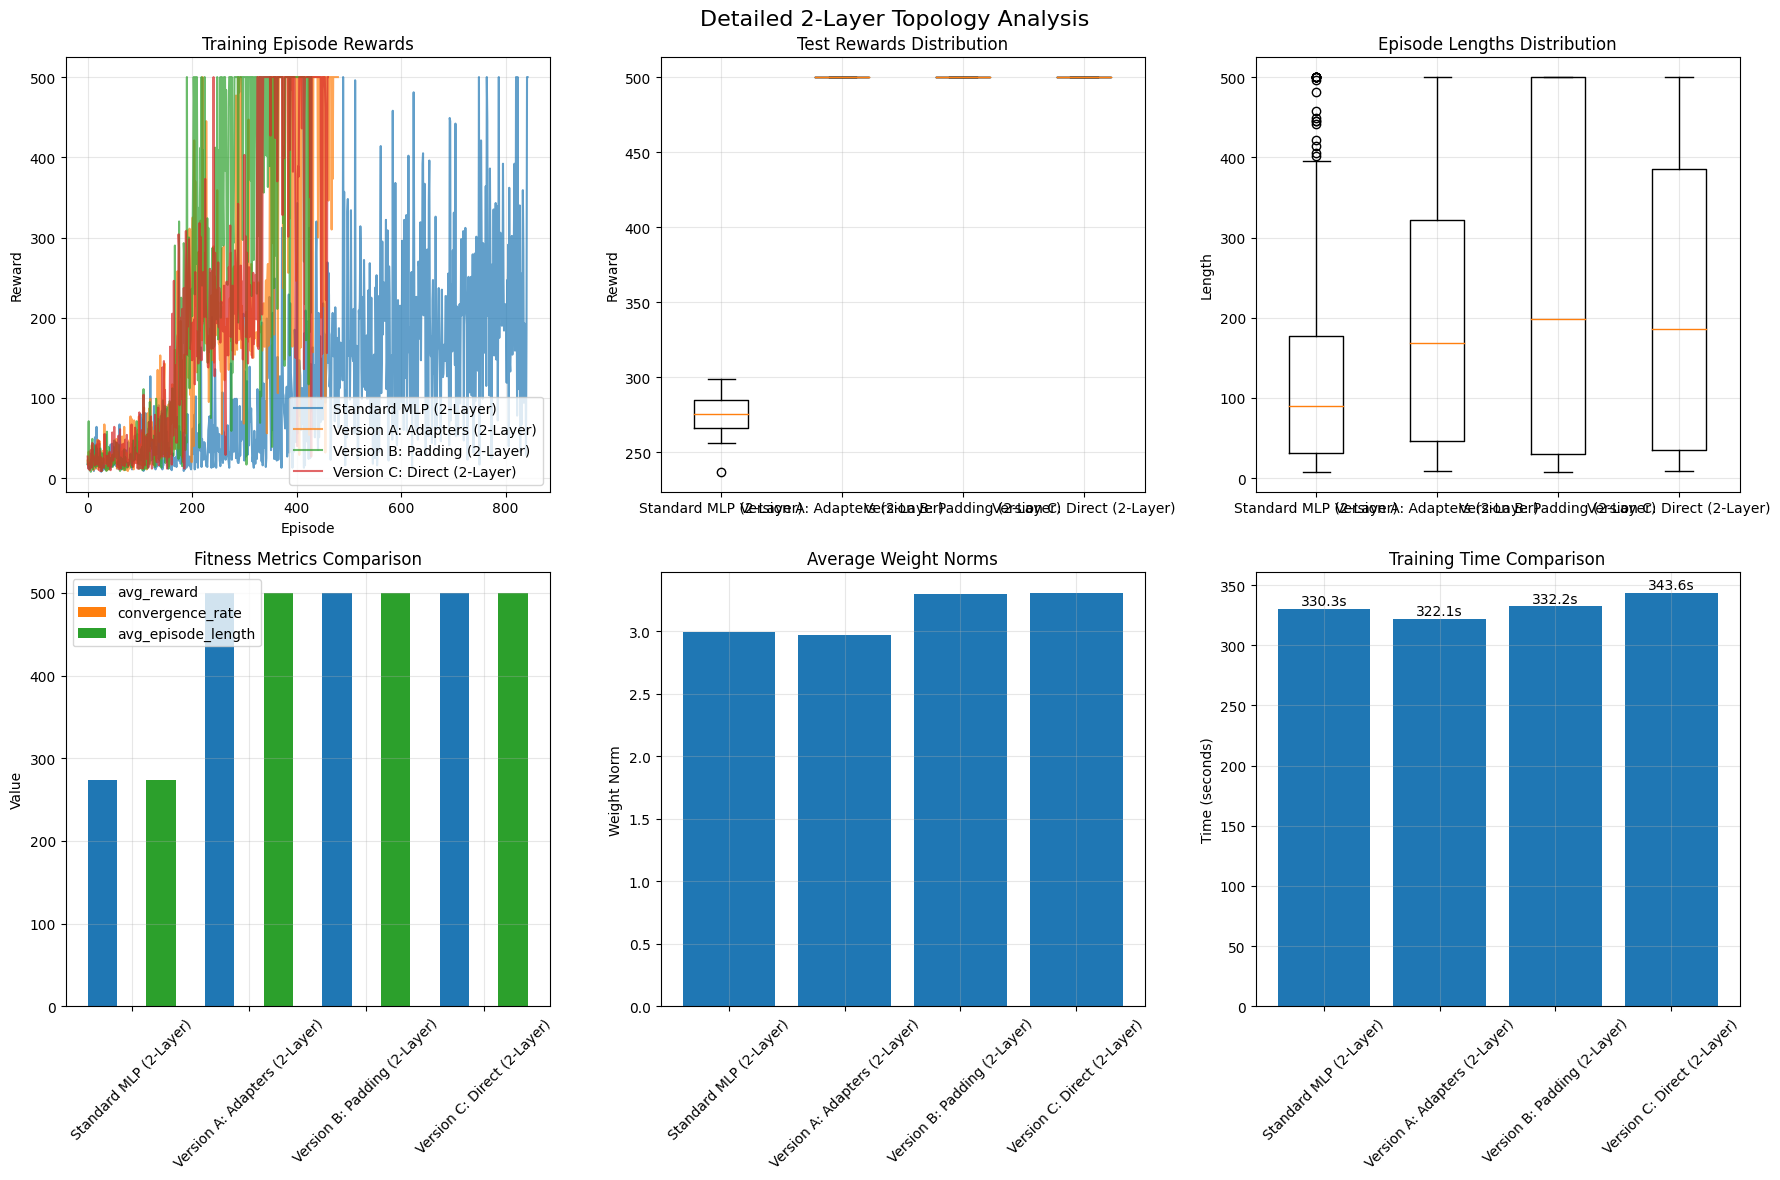


📊 DETAILED ANALYSIS SUMMARY (2-Layer Topologies)

🎯 Standard MLP (2-Layer)
--------------------------------------------------------------------------------
🏃 FITNESS METRICS:
  Average Reward: 273.60 ± 17.21
  Reward Range: 237 - 299
  Convergence Rate: 1.30%
  Average Episode Length: 273.6
  Training Time: 330.3s

🛤️ TRAJECTORY METRICS:
  Episode Length: 273.6 ± 17.2
  Action Diversity: 2 unique actions
  Actions per Episode: 273.6

⚖️ WEIGHT STATISTICS:
  mlp_extractor.policy_net.0.weight: mean=0.0090, std=0.2036, norm=3.2546
  mlp_extractor.policy_net.0.bias: mean=-0.0100, std=0.1215, norm=0.9674
  mlp_extractor.policy_net.2.weight: mean=0.0047, std=0.1843, norm=11.7962
  mlp_extractor.policy_net.2.bias: mean=-0.0381, std=0.1067, norm=0.9002
  mlp_extractor.value_net.0.weight: mean=0.0030, std=0.1414, norm=2.2590
  mlp_extractor.value_net.0.bias: mean=0.0312, std=0.3449, norm=2.7492
  mlp_extractor.value_net.2.weight: mean=0.0010, std=0.2569, norm=16.4388
  mlp_extractor.value_net.

In [ ]:
"""Run detailed analysis of all policies."""
print("🚀 Starting Detailed 2-Layer Topology Analysis")
print("=" * 80)

# Test all policies
results = []

# Test Standard MLP
results.append(test_policy_detailed(StandardMLPPolicy, "Standard MLP (2-Layer)"))

# Test Version A: Adapters
results.append(test_policy_detailed(VersionA_AdapterPolicy_2Layers, "Version A: Adapters (2-Layer)"))

# Test Version B: Padding
results.append(test_policy_detailed(VersionB_PaddingPolicy_2Layers, "Version B: Padding (2-Layer)"))

# Test Version C: Direct
results.append(test_policy_detailed(VersionC_DirectPolicy_2Layers, "Version C: Direct (2-Layer)"))

# Test Version D: Masking
results.append(test_policy_detailed(VersionD_MaskingPolicy_2Layers, "Version D: Masking (2-Layer)"))

# Create detailed visualizations
plot_detailed_results(results)

# Print detailed summary
print_detailed_summary(results)

# Save detailed results to JSON
with open('detailed_topology_results_2layers.json', 'w') as f:
    # Convert numpy arrays and scalars to Python types for JSON serialization
    def convert_numpy(obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, dict):
            return {key: convert_numpy(value) for key, value in obj.items()}
        elif isinstance(obj, list):
            return [convert_numpy(item) for item in obj]
        else:
            return obj
    
    json_results = convert_numpy(results)
    json.dump(json_results, f, indent=2)

print(f"\n✅ Detailed analysis completed!")
print("📁 Files created:")
print("  - detailed_topology_analysis_2layers.png (visualizations)")
print("  - detailed_topology_results_2layers.json (raw data)")